In [46]:
import numpy as np
#from scipy.integrate import solve_ivp 
import matplotlib.pyplot as plt
import time
from tabulate import tabulate
import pandas as pd
np.set_printoptions(threshold = np.inf)

In [47]:

# coeficient of u, u' and u'' , just modify them if you want to slove another equation
#----------------------------------------------------------------------------------------------------------------------------------------
def cft_u(x):return -(G2(x)*x+Cx(x)*G1(x)+Dx(x)*G(x))*A(x)/G(x)

def cft_u1(x):return -(2*G1(x)*x+Cx(x)*G(x))*A(x)/G(x)

def cft_u2(x):return -A(x)*x

#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
#These are part of the coeficients :

v=0.28170155790877400592334265111700731965718026322934836713673192303460348039980182970389127012050565043465821289355805066025672639447355195448802045593143670911913641107077463154220342848408998160904869975888148775790690583653893672393609101177960611295355370425929891516847791327020041738790737066438709875972148984910134433579627631902521061632838103401850319253976008102644621765838676176099271395298953039171688583280447923068135052230749778606605254003317895279533270534639578257130709831686526204

lamda=1/2

S=(3*(1+v**2))/lamda
alpha=1/(2*(3+v**2))


#To verify if the coeficient functions are correct, check it with  https://www.desmos.com/calculator/fomftfe3ou?lang=zh-CN   . 


def A(x):
    return (3-v**2-v**2*x**2*(1+v**2))*(1-x**2)/(1-v**2*x**2)

def B(x):
    return (1-v**2*x**2)/(3+6*v**2-v**4)

def AB(x):
    return c*x**4+b*x**2+d
    
def A1(x):
    return -(2*x*(v**6*x**4+v**4*(x**4-2*x**2+2)-v**2*(2*x**2+3)+3))/((1-v**2*x**2)**2)

def B1(x):
    return 2*v**2*x/(v**4-6*v**2-3)

def B2(x):
    return 2*v**2/(v**4-6*v**2-3)

def C(x):# Correct
    return 3*E(x)+B1(x)/B(x)+omega(x)

def D(x):
    #print (omega(x))
    return E(x)**2/2+(3*E(x)*B1(x))/(2*B(x))-(B1(x)/B(x))**2+(2*b+12*c*x**2)/(A(x)*B(x))+(3*E(x)*omega(x))/2

def Cx(x):# Correct
    return (3*E(x)+B1(x)/B(x))*x+omegax(x)

def Dx(x):
    #print (omega(x))
    return (E(x)**2/2+(3*E(x)*B1(x))/(2*B(x))-(B1(x)/B(x))**2+(2*b+12*c*x**2)/(A(x)*B(x)))*x+(3*E(x)*omegax(x))/2

d=(3-v**2)/(3+6*v**2-v**4)
b=-(3+v**4)/(3+6*v**2-v**4)
c=(v**2*(1+v**2))/(3+6*v**2-v**4)

def E(x):# Correct
    return (2*x*(b+2*c*x**2))/(A(x)*B(x))

def F(x):# Correct
    return (2*x*(3+v**2+x**2))/(B(x)**2*A(x))*((-1+2*v**2-v**4)/(3+6*v**2-v**4)**2)

def Fx(x):# Correct
    return (2*(3+v**2+x**2))/(B(x)**2*A(x))*((-1+2*v**2-v**4)/(3+6*v**2-v**4)**2)

def omega(x):# Correct
    return (1/F(x))*(4*B2(x)/B(x)+E(x)**2-2*((2*b+12*c*x**2)/(A(x)*B(x))))

def omegax(x):# Correct
    return (1/Fx(x))*(4*B2(x)/B(x)+E(x)**2-2*((2*b+12*c*x**2)/(A(x)*B(x))))


def G(x):      # Let h00=G(x)*u(x)
    return (1-x**2)**(-2)

def G1(x):
    return 4*x*(1-x**2)**(-3)

def G2(x):
    return 4*(5*x**2+1)*(1-x**2)**(-4)




def L(k,n):
    return 2*k+abs(n)

def m(k,n):
    return L(k,n)*(L(k,n)+2)-n**2

#----------------------------------------------------------------------------------------------------------------------------------------






def YQ_u(a,b):
     return np.cos(b*np.pi*a/2)  # u
def YQ_u1(a,b):
     return -b*np.pi*np.sin(b*np.pi*a/2)/2  # u'
def YQ_u2(a,b):
     return -b**2*np.pi**2*np.cos(b*np.pi*a/2)/4  # u''
def YQ_chebyshev(myN):
    sList=np.linspace(0,2,myN+2)[1:-1]  # omit the boundary samples, this gives better convergence
    #print(sList)
    Phi=np.array([[YQ_u(a,b)*a for a in sList] for b in range(myN)] ) #this is a shortcut method to create the nested list
    
    myL=np.array([[   cft_u1(a-1)  *YQ_u1(a,b)+  cft_u2(a-1)*YQ_u2(a,b)    +  cft_u(a-1)*YQ_u(a,b)  
                for a in sList] for b in range(myN)])
    #print(myL)
    evals,evecs = np.linalg.eig(np.dot(myL,np.linalg.inv(Phi)))
    return [evals,evecs]



def u(a,b):
    coefList=np.zeros(b+1); coefList[-1]=1;
    return np.polynomial.chebyshev.Chebyshev(coefList)(a)  # u

def u1(a,b):
    coefList=np.zeros(b+1); coefList[-1]=1;
    return np.polynomial.chebyshev.Chebyshev(np.polynomial.chebyshev.chebder(coefList,m=1))(a)   # u'

def u2(a,b):
    coefList=np.zeros(b+1); coefList[-1]=1;
    return np.polynomial.chebyshev.Chebyshev(np.polynomial.chebyshev.chebder(coefList,m=2))(a)  # u''
    
def robies_chebyshev(myN):
    sList=np.cos(np.linspace(0.,1.,myN+2)[1:-1]*np.pi)  # omit the boundary samples, this gives better convergence
    #print(sList)
    Phi=np.array([[u(a,b)*a for b in range(myN)] for a in sList]  ) #this is a shortcut method to create the nested list
    
    myL=np.array([[   cft_u1(a)  *u1(a,b)+  cft_u2(a)*u2(a,b)    +  cft_u(a)*u(a,b)  
              for b in range(0,myN)] for a in sList] )
    #print(myL)
    evals,evecs = np.linalg.eig(np.dot(myL,np.linalg.inv(Phi)))
    return [evals,evecs]

In [14]:
x1=0.3

print(G(x1),G1(x1),G2(x1))

1.2075836251660426 1.5924179672519243 8.457897628261136


In [4]:
x1=0.3

print(C(x1),D(x1),A(x1)*B(x1), E(x1))

-9.076739773647418 5.148330538713044 0.7639468530944659 -0.676983296533718


### Here we can see:
### 1. For odd Ns, the result are weirdly large and divergent.
### 2. For even Ns, the first 2 eigenvalues are also weirdly large and divergent, but after that, they become real and stable.

In [51]:
for i in range(100, 110):
    print('N=',i,':',np.sort(robies_chebyshev(i)[0])[0:8],'\n')

N= 100 : [-2906.16611381+0.j -2905.25565726+0.j    -6.43919646+0.j
    12.70921934+0.j    29.86175454+0.j    55.14410966+0.j
    83.57318737+0.j   121.33655256+0.j] 

N= 101 : [-2.51333149e+05 +0.j         -2.84916590e+04 +0.j
 -2.96307833e+03 +0.j         -2.54695519e+02 +0.j
  3.26128390e+01 +0.j          3.26939703e+01-33.23781388j
  3.26939703e+01+33.23781388j  9.91912472e+01 +0.j        ] 

N= 102 : [-3022.45160488+0.j -3021.54114377+0.j    -6.43975562+0.j
    12.71138113+0.j    29.86196587+0.j    55.14958914+0.j
    83.60155099+0.j   121.36154964+0.j] 

N= 103 : [-7.98160938e+04-1.0885826e+05j -7.98160938e+04+1.0885826e+05j
 -3.07978243e+03+0.0000000e+00j -1.50809597e+03+0.0000000e+00j
  1.42683217e+01+0.0000000e+00j  2.91076693e+01+0.0000000e+00j
  8.76734328e+01-7.1276186e+01j  8.76734328e+01+7.1276186e+01j] 

N= 104 : [-3141.01719796+0.j -3140.10673258+0.j    -6.43936993+0.j
    12.71103297+0.j    29.86740884+0.j    55.15810796+0.j
    83.59975925+0.j   121.38108527+0.j] 

N= 

### 

In [52]:
for i in range(50, 55):
    print('N=',2*i,':',np.sort(robies_chebyshev(2*i)[0])[2:12],'\n')

N= 100 : [ -6.43919646+0.j  12.70921934+0.j  29.86175454+0.j  55.14410966+0.j
  83.57318737+0.j 121.33655256+0.j 161.02291738+0.j 211.17634195+0.j
 261.96717366+0.j 324.57515139+0.j] 

N= 102 : [ -6.43975562+0.j  12.71138113+0.j  29.86196587+0.j  55.14958914+0.j
  83.60155099+0.j 121.36154964+0.j 161.01174513+0.j 211.22444022+0.j
 262.13858736+0.j 324.66920361+0.j] 

N= 104 : [ -6.43936993+0.j  12.71103297+0.j  29.86740884+0.j  55.15810796+0.j
  83.59975925+0.j 121.38108527+0.j 161.08744962+0.j 211.27461017+0.j
 262.10511705+0.j 324.75337697+0.j] 

N= 106 : [ -6.4398791 +0.j  12.71298691+0.j  29.86756616+0.j  55.16294467+0.j
  83.6252021 +0.j 121.40345635+0.j 161.07706055+0.j 211.31768279+0.j
 262.25984425+0.j 324.8382087 +0.j] 

N= 108 : [ -6.43952408+0.j  12.71264695+0.j  29.87244839+0.j  55.17058767+0.j
  83.62345693+0.j 121.42088799+0.j 161.14528114+0.j 211.36278955+0.j
 262.22907321+0.j 324.91414216+0.j] 



In [40]:
i=100
print('N=',2*i,':',np.sort(robies_chebyshev(2*i)[0])[0:12],'\n')

N= 200 : [-1.15135676e+04+0.j -1.15126570e+04+0.j -6.44089160e+00+0.j
  1.27270831e+01+0.j  2.99179025e+01+0.j  5.52831684e+01+0.j
  8.38372834e+01+0.j  1.21783934e+02+0.j  1.61679845e+02+0.j
  2.12181565e+02+0.j  2.63385838e+02+0.j  3.26443039e+02+0.j] 



In [53]:
for i in range(100, 103):
    print('N=',i,':',np.sort(YQ_chebyshev(i)[0]),'\n')

N= 100 : [-8.99764385e+04-1.13220020e+04j -8.99764385e+04+1.13220020e+04j
 -6.95494651e+04-7.00776479e+03j -6.95494651e+04+7.00776479e+03j
 -5.59665963e+04-4.87077041e+03j -5.59665963e+04+4.87077041e+03j
 -4.59193222e+04-3.57358124e+03j -4.59193222e+04+3.57358124e+03j
 -3.80794161e+04-2.69789604e+03j -3.80794161e+04+2.69789604e+03j
 -3.17628025e+04-2.06776985e+03j -3.17628025e+04+2.06776985e+03j
 -2.65656837e+04-1.59479208e+03j -2.65656837e+04+1.59479208e+03j
 -2.22276840e+04-1.22898882e+03j -2.22276840e+04+1.22898882e+03j
 -1.85701452e+04-9.39595839e+02j -1.85701452e+04+9.39595839e+02j
 -1.54647009e+04-7.06302256e+02j -1.54647009e+04+7.06302256e+02j
 -1.28157895e+04-5.14673982e+02j -1.28157895e+04+5.14673982e+02j
 -1.05502448e+04-3.53101316e+02j -1.05502448e+04+3.53101316e+02j
 -8.61076258e+03-2.08449226e+02j -8.61076258e+03+2.08449226e+02j
 -6.97966039e+03+0.00000000e+00j -6.92357514e+03+0.00000000e+00j
 -5.68456916e+03+0.00000000e+00j -5.38694658e+03+0.00000000e+00j
 -4.50529950e+03

The total time is :
71.73312044143677


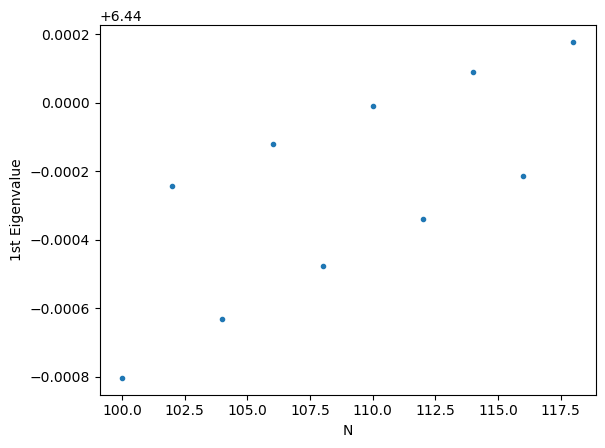

In [35]:
n=0
k=0

sstart = time.time()

RangeStart=50
RangeEnd=60
feval=[]
#robies_eigen=np.sort(robies_chebyshev(100)[0])[1]



for myN in range(RangeStart,RangeEnd):
    #eigenpairs=[Robies_eigen, np.sort(YQ_chebyshev(myN)[0])[1]]
    #eigenpairs=[np.sort(robies_chebyshev(myN)[0])[1], np.sort(YQ_chebyshev(myN)[0])[1]]
    #feval.append(eigenpairs)
    feval.append(abs(np.sort(robies_chebyshev(myN*2)[0])[2]))
   

    
plt.plot([x*2 for x in range(RangeStart,RangeEnd)],feval,'.')
plt.xlabel("N")
plt.ylabel("1st Eigenvalue")



eend = time.time()
totaltime=eend-sstart
print("The total time is :")
print(totaltime)



In [33]:
[x*2 for x in range(5,7)]

[10, 12]

In [49]:
np.sort(YQ_chebyshev(1000)[0])[0:8]

array([-12942889.52221218-539077.67377999j,
       -12942889.52221218+539077.67377999j,
       -12068364.65795475-407878.69028328j,
       -12068364.65795475+407878.69028328j,
       -11417882.85656149-337333.46599334j,
       -11417882.85656149+337333.46599334j,
       -10886801.06236716-291640.67276568j,
       -10886801.06236716+291640.67276568j])

In [16]:
np.sort(robies_chebyshev(3)[0])[0:8]

array([-1895.28226491   +0.j        ,   959.63871959-1648.60842676j,
         959.63871959+1648.60842676j])

In [17]:
np.sort(robies_chebyshev(4)[0])[0:8]

array([-8.07042783, -5.81703406, -2.56524907, 62.37471254])

In [10]:
np.sort(robies_chebyshev(200)[0])[0:8]

array([-1.15135676e+04+0.j, -1.15126570e+04+0.j, -6.44089160e+00+0.j,
        1.27270831e+01+0.j,  2.99179025e+01+0.j,  5.52831684e+01+0.j,
        8.38372834e+01+0.j,  1.21783934e+02+0.j])

In [24]:
#np.sort(robies_chebyshev(100)[0])

In [25]:
#np.sort(YQ_chebyshev(50)[0])

In [26]:
#np.sort(YQ_chebyshev(100)[0])

In [27]:
#np.sort(YQ_chebyshev(1000)[0])

### Things below are not related to what we're doing

In [23]:
for i in range(100, 120):
    print('N=',i,':',np.sort(robies_chebyshev(i)[0])[0:8],'\n')

N= 100 : [-2906.16611381+0.j -2905.25565726+0.j    -6.43919646+0.j
    12.70921934+0.j    29.86175454+0.j    55.14410966+0.j
    83.57318737+0.j   121.33655256+0.j] 

N= 101 : [-2.51333149e+05 +0.j         -2.84916590e+04 +0.j
 -2.96307833e+03 +0.j         -2.54695519e+02 +0.j
  3.26128390e+01 +0.j          3.26939703e+01-33.23781388j
  3.26939703e+01+33.23781388j  9.91912472e+01 +0.j        ] 

N= 102 : [-3022.45160488+0.j -3021.54114377+0.j    -6.43975562+0.j
    12.71138113+0.j    29.86196587+0.j    55.14958914+0.j
    83.60155099+0.j   121.36154964+0.j] 

N= 103 : [-7.98160938e+04-1.0885826e+05j -7.98160938e+04+1.0885826e+05j
 -3.07978243e+03+0.0000000e+00j -1.50809597e+03+0.0000000e+00j
  1.42683217e+01+0.0000000e+00j  2.91076693e+01+0.0000000e+00j
  8.76734328e+01-7.1276186e+01j  8.76734328e+01+7.1276186e+01j] 

N= 104 : [-3141.01719796+0.j -3140.10673258+0.j    -6.43936993+0.j
    12.71103297+0.j    29.86740884+0.j    55.15810796+0.j
    83.59975925+0.j   121.38108527+0.j] 

N= 

In [49]:
sstart=time.time()
print("{0:.55f}".format(robies_chebyshev(100)[0][-12]))
eend = time.time()
totaltime=eend-sstart
print("The total time is :")
print(totaltime)

197.1502996445448445683723548427224159240722656250000000000-292.5615782294117934725363738834857940673828125000000000000j
The total time is :
6.323100566864014


In [18]:
%timeit -n 1 -r 1 "{0:.55f}".format(robies_chebyshev(50)[0][-12])

1.25 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [19]:
%timeit -n 1 -r 1 "{0:.55f}".format(robies_chebyshev(100)[0][-12])

6.82 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [50]:
%timeit -n 1 -r 1 "{0:.55f}".format(YQ_chebyshev(50)[0][-12])

328 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [21]:
%timeit -n 1 -r 1 "{0:.55f}".format(YQ_chebyshev(100)[0][-12])

1.28 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [37]:
n=0
k=0

sstart = time.time()

RangeStart=50
RangeEnd=60
feval=[]
#robies_eigen=np.sort(robies_chebyshev(100)[0])[1]



for myN in range(RangeStart,RangeEnd):
    #eigenpairs=[Robies_eigen, np.sort(YQ_chebyshev(myN)[0])[1]]
    eigenpairs=[np.sort(robies_chebyshev(myN)[0])[1], np.sort(YQ_chebyshev(myN)[0])[1]]
    feval.append(eigenpairs)
   

    
plt.plot(range(RangeStart,RangeEnd),feval,'.')
plt.xlabel("N")
plt.ylabel("1st Eigenvalue")



eend = time.time()
totaltime=eend-sstart
print("The total time is :")
print(totaltime)



C:\Users\Whatever\AppData\Local\Temp\ipykernel_20200\4173631224.py:51: RuntimeWarning: divide by zero encountered in scalar divide
  return 1/F(x)*(4*B2(x)/B(x)+E(x)**2-2*((2*b+12*c*x**2)/(A(x)*B(x))))
C:\Users\Whatever\AppData\Local\Temp\ipykernel_20200\4173631224.py:76: RuntimeWarning: invalid value encountered in scalar multiply
  myL=np.array([[   cft_u1(a-1)  *YQ_u1(a,b)+  cft_u2(a-1)*YQ_u2(a,b)    +  cft_u(a-1)*YQ_u(a,b)
C:\Users\Whatever\AppData\Local\Temp\ipykernel_20200\4173631224.py:38: RuntimeWarning: invalid value encountered in scalar multiply
  return (E(x))**2/2+(3*E(x)*B1(x))/(2*B(x))-(B1(x)/B(x))**2+(2*b+12*c*x**2)/(A(x)*B(x))+(3*E(x)*omega(x))/2


LinAlgError: Array must not contain infs or NaNs

Text(0, 0.5, '2nd Eigenvalue')

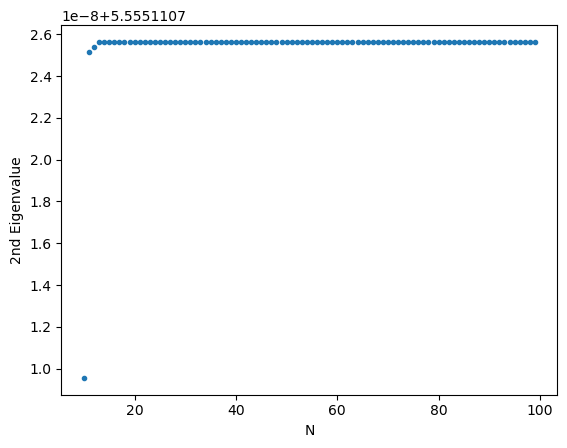

In [27]:
plt.plot(range(RangeStart,RangeEnd),feval2,'.')
plt.xlabel("N")
plt.ylabel("2nd Eigenvalue")

In [60]:

nRange=3  #Range of n, the program is solving the problem up to n=nRange
kRange=3  #Range of k, the program is solving the problem up to k=nRange
number_of_evals=8  # The amount of eigenvalues we want to analyze for each group of n,k

N=100 #The amount of basic functions we use, larger n means better accuracy and longer time
lamda=1/2 # Value of Λ, a coefficient of our equation

'''
The code above can be changed to get result for different cases, while the below are source codes 
'''


sstart = time.time()
tablelist1=[]
head1=["n","k","order:"]+list(range(1,number_of_evals+1))


for n in range (nRange+1):
    for k in range (kRange+1):
        initial=[n,k," "]
        elist=np.sort(robies_chebyshev(N)[0])[0:number_of_evals].tolist()
        tablelist1.append(initial+elist)

        
print(tabulate(tablelist1, headers=head1, tablefmt="grid"))
eend = time.time()
totaltime=eend-sstart
print("The total time is :")
print(totaltime)
    
#Robie's    (for N=100)

+-----+-----+----------+--------------+----------+----------+---------+---------+---------+----------+----------+
|   n |   k | order:   |            1 |        2 |        3 |       4 |       5 |       6 |        7 |        8 |
+=====+=====+==========+==============+==========+==========+=========+=========+=========+==========+==========+
|   0 |   0 |          |  2.28176e-13 |  1.85252 |  5.55511 | 11.1094 | 18.5153 | 27.7725 |  38.8813 |  51.8415 |
+-----+-----+----------+--------------+----------+----------+---------+---------+---------+----------+----------+
|   0 |   1 |          |  2.20152     |  4.10276 |  7.79344 | 13.3448 | 20.7496 | 30.0064 |  41.1149 |  54.075  |
+-----+-----+----------+--------------+----------+----------+---------+---------+---------+----------+----------+
|   0 |   2 |          |  6.60147     |  8.60169 | 12.2722  | 17.8163 | 25.2187 | 34.4744 |  45.5823 |  58.542  |
+-----+-----+----------+--------------+----------+----------+---------+---------+-------

The total time is :
306.6128387451172


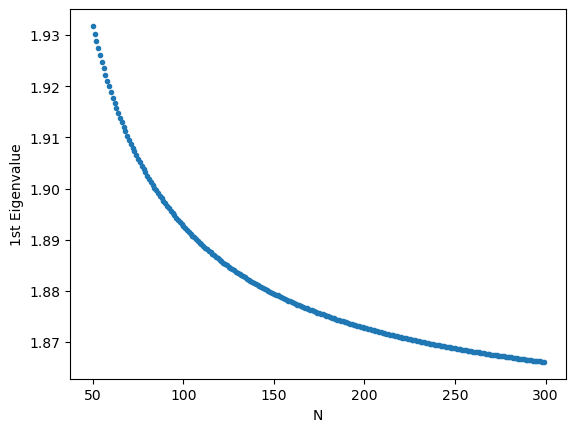

In [29]:
n=0
k=0

sstart = time.time()

RangeStart=50
RangeEnd=300
feval=[]

for myN in range(RangeStart,RangeEnd):
    feval.append(np.sort(YQ_chebyshev(myN)[0])[1])


    
plt.plot(range(RangeStart,RangeEnd),feval,'.')
plt.xlabel("N")
plt.ylabel("1st Eigenvalue")



eend = time.time()
totaltime=eend-sstart
print("The total time is :")
print(totaltime)



Text(0, 0.5, 'Relative Difference^(1/2)')

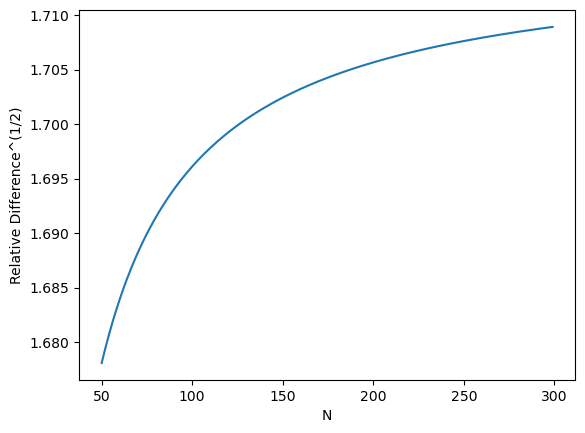

In [49]:
eigenInv=[]
for i in feval:
    eigenInv.append(np.e**(1/i))
plt.plot(range(RangeStart,RangeEnd),eigenInv)
plt.xlabel("N")
plt.ylabel("Relative Difference^(1/2)")


#No result, can't find a function of 1st eigenvalue

# Difference Test -  Mean Absolute Deviation


The total time is :
133.17547702789307


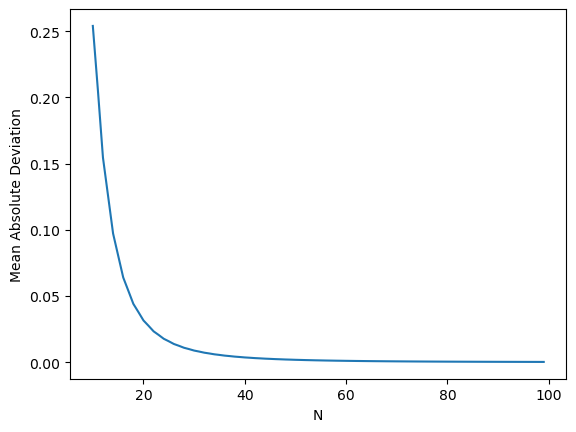

In [20]:
n=1
k=1

sstart = time.time()

RangeStart=10
RangeEnd=100
evals= robies_chebyshev(RangeStart-1)[0]
evals5_record=np.sort(evals)[0:5]
RdiffL=[]
#AdiffL=[]

for myN in range(RangeStart,RangeEnd):

    evals= robies_chebyshev(myN)[0]
    evals5=np.sort(evals)[0:5]
    Rdiff=0  #relative difference
    #Adiff=0  #absolute difference
    for i in range(5):
        Rdiff+=abs(evals5[i]-evals5_record[i])
        #Adiff+=abs(evals5[i]-analysis[i])
    Rdiff=Rdiff/5
    #Adiff=Adiff/5
    RdiffL.append(Rdiff)
    #AdiffL.append(Adiff)
    evals5_record=evals5
    
'''
print("The Relative Difference is:")
print(RdiffL)
print("The Absolute Difference is:")
print(AdiffL)
'''

                               
plt.plot(range(RangeStart,RangeEnd),RdiffL)
plt.xlabel("N")
plt.ylabel("Mean Absolute Deviation")


#ax2.plot(range(RangeStart,RangeEnd),AdiffL)
#ax2.set_title("Absolute Difference vs N")





eend = time.time()
totaltime=eend-sstart
print("The total time is :")
print(totaltime)

Text(0, 0.5, 'Relative Difference^(-1/3)')

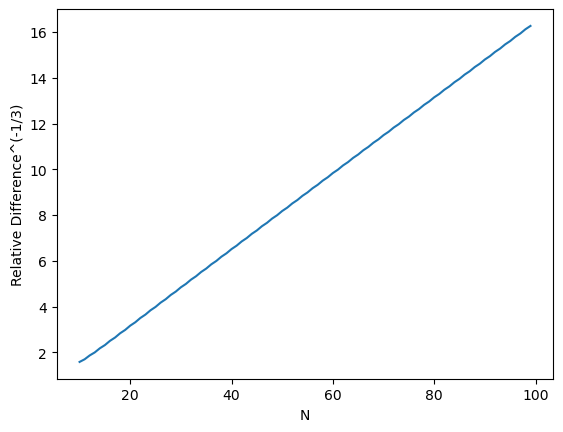

In [24]:
RdiffInv=[]
for i in RdiffL:
    RdiffInv.append(1/i**(1/3))
plt.plot(range(RangeStart,RangeEnd),RdiffInv)
plt.xlabel("N")
plt.ylabel("Relative Difference^(-1/3)")


### Therefore, the Relative Difference is decreasing in the order of 1/N^4 


# Difference Test - Root mean square


The total time is :
461.1388039588928


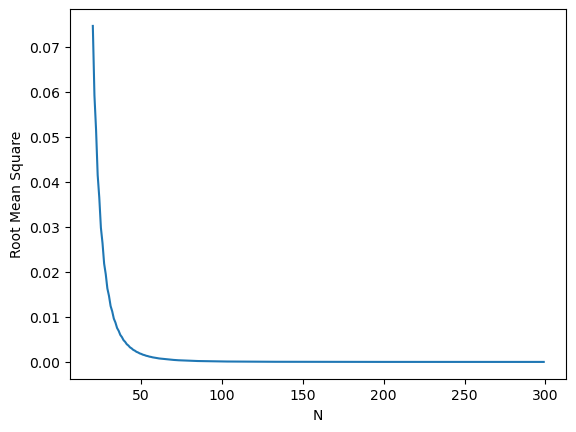

In [38]:

sstart = time.time()

RangeStart=20
RangeEnd=300
evals= chebyshev(RangeStart-1)[0]
evals5_record=np.sort(evals)[0:4]
RMSdiffL=[]
#AdiffL=[]

for myN in range(RangeStart,RangeEnd):

    evals= chebyshev(myN)[0]
    evals5=np.sort(evals)[0:4]
    Rdiff=0  #relative difference
    #Adiff=0  #absolute difference
    for i in range(4):
        Rdiff+=(evals5[i]-evals5_record[i])**2
        #Adiff+=abs(evals5[i]-analysis[i])
    Rdiff=Rdiff**(1/2)/2
    #Adiff=Adiff/5
    RMSdiffL.append(Rdiff)
    #AdiffL.append(Adiff)
    evals5_record=evals5
    


                               
plt.plot(range(RangeStart,RangeEnd),RMSdiffL)
plt.xlabel("N")
plt.ylabel("Root Mean Square")


#ax2.plot(range(RangeStart,RangeEnd),AdiffL)
#ax2.set_title("Absolute Difference vs N")





eend = time.time()
totaltime=eend-sstart
print("The total time is :")
print(totaltime)

Text(0, 0.5, 'Root Mean Square^(-1/4)')

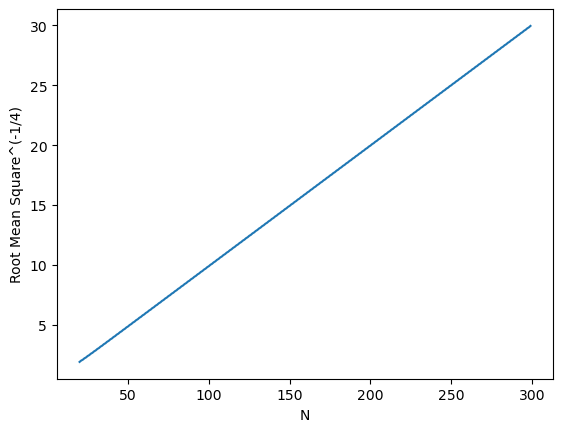

In [40]:
RdiffInv=[]
for i in RMSdiffL:
    RdiffInv.append(1/i**(1/4))
plt.plot(range(RangeStart,RangeEnd),RdiffInv)
plt.xlabel("N")
plt.ylabel("Root Mean Square^(-1/4)")


###  The Root Mean Square is also decreasing in the order of 1/N^4 


# Sort the eigenvalues and trace the index


In [102]:

nRange=3  #Range of n, the program is solving the problem up to n=nRange
kRange=3  #Range of k, the program is solving the problem up to k=nRange
number_of_evals=8  # The amount of eigenvalues we want to analyze for each group of n,k

lamda=1/2 # Value of Λ, a coefficient of our equation

'''
The code above can be changed to get result for different cases, while the below are source codes 
'''



sstart = time.time()
total_evals=[]

tablelist=[]
tablerow=["Order Of Smallest Eigenvalues"," ","n","k","order"," ","value"]
head=["Order Of Smallest Eigenvalues"," ","n","k","order"," ","value"]

for n in range (nRange+1):
    for k in range (kRange+1):
        elist=np.sort(chebyshev(1000)[0])[0:number_of_evals].tolist()
        total_evals.append(elist)
#print(total_evals)            
total_evals=np.array(total_evals)

for i in range(number_of_evals*(nRange+1)*(kRange+1)):
    tablerow[0]=i+1
    min_xy = np.where( total_evals ==  total_evals.min() )
    a=(min_xy[0][0], min_xy[1][0])
    tablerow[2]=a[0]//(kRange+1)
    tablerow[3]=a[0]%(kRange+1)
    tablerow[4]=a[1]+1
    tablerow[6]=total_evals[a[0]][a[1]]
    total_evals[a[0]][a[1]]=9999999999999999999999999999
    #print(tablerow)
    tablelist.append(tablerow)
    #print(tablelist)
    tablerow=["Order Of Smallest Eigenvalues"," ","n","k","order"," ","value"]
    #print(total_evals)
    
    
print(tabulate(tablelist, headers=head, tablefmt="grid"))


eend = time.time()
totaltime=eend-sstart
print("The total time is :")
print(totaltime)
    

+---------------------------------+-----+-----+-----+---------+-----+-----------+
|   Order Of Smallest Eigenvalues |     |   n |   k |   order |     |     value |
+=================================+=====+=====+=====+=========+=====+===========+
|                               1 |     |   0 |   0 |       1 |     |   0       |
+---------------------------------+-----+-----+-----+---------+-----+-----------+
|                               2 |     |   0 |   0 |       2 |     |   1.85661 |
+---------------------------------+-----+-----+-----+---------+-----+-----------+
|                               3 |     |   0 |   1 |       1 |     |   2.20143 |
+---------------------------------+-----+-----+-----+---------+-----+-----------+
|                               4 |     |   1 |   0 |       1 |     |   2.46767 |
+---------------------------------+-----+-----+-----+---------+-----+-----------+
|                               5 |     |   0 |   1 |       2 |     |   4.10662 |
+---------------

### The cells below are just for testing purpose, not related to our work.

In [87]:
for i in range(number_of_evals*(nRange+1)*(kRange+1)):
    print(i)

0
1
2
3
4
5
6
7


In [75]:


a = np.array([[1, 1], [2, 24], [3, 3],[24,24]])
max_xy = np.where(a == a.max() )
max_xy

(array([1, 3, 3], dtype=int64), array([1, 0, 1], dtype=int64))

In [98]:
b=[1]
a=[]
a.append(b)
print(a)
b=2
print(a)
a.append(b)
print(a)

[[1]]
[[1]]
[[1], 2]
